<a href="https://colab.research.google.com/github/keyonai/OCR-practice/blob/main/updated_Compare_3_OCRs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 75 not upgraded.
Upload your Pharmaceutical SDF (PDF file):


Saving pharmaceutical-sdf-page3-certificate-quality (1).pdf to pharmaceutical-sdf-page3-certificate-quality (1) (3).pdf

Uploaded: pharmaceutical-sdf-page3-certificate-quality (1) (3).pdf
Attempting direct text extraction (without OCR):
--------------------------------------------------
Certificate of Quality 
This product is manufactured in compliance with our ISO 9001 certified quality management system.
Issued by Cytiva Westborough Quality Assurance
This document has been electronically produced and is valid without a signature.
ÄKTA is a trademark of Global Life Sciences Solutions USA LLC or an affiliate doing business as Cytiva. 
Cytiva and the Drop logo are trademarks of Global Life Sciences IP Holdco LLC or an affiliate.
cytiva.com 
29190939 Rev AD
Product: ÄKTA™ ready G
Here's your pharmaceutical document as an image:


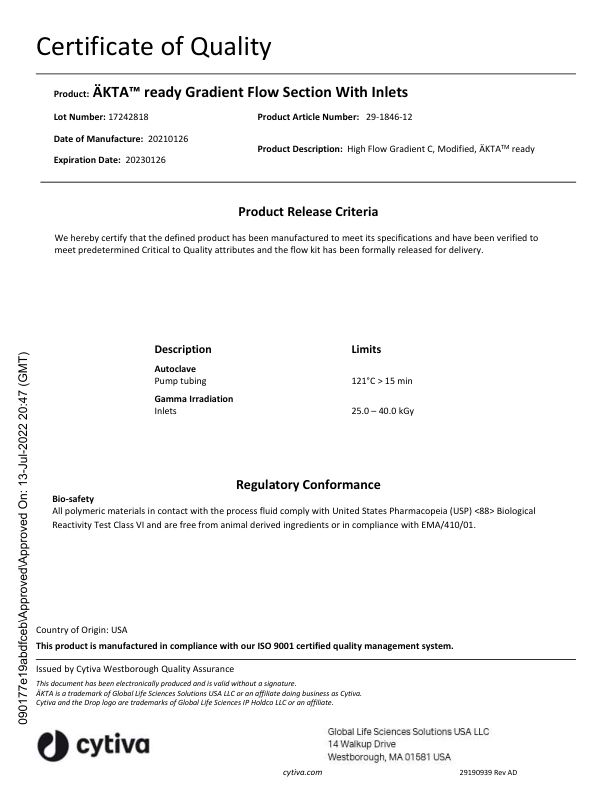

OCR EXTRACTED TEXT
090177e19abdfceb\Approved\Approved On: 13-Juk-2022 20:47 (GMT)

Certificate of Quality

Product: AKTA™ ready Gradient Flow Section With Inlets
Lot Number: 17242818 Product Article Number: 29-1846-12
Dake of Manufacture: 20210126

Product Description: High Flow Gradient C, Modified, AKTA™ ready
Expleation Date: 20230126

Product Release Criterla

We hereby certify that the defined product has been manufactured to meet Its specifications and have been verified ta
meet predetermined Critical to Quality attributes and the flow kit has been formally released for delivery.

Description Umits
futadave

Pump tubing 121°C >15 min
Gamma bradiation

inlets. 25.0 ~ 40.0 kGy

Regulatory Confermance
Blo-safety
All polymeric materials In contact with the process fluld comply with United States Pharmacopela (USP) <88> Bictogical
Reacthty Test Class VI and are free fram animal dertved Ingredients or In compWance with EMA/410/01.

Country of Origin: USA
This product Is manufactured In

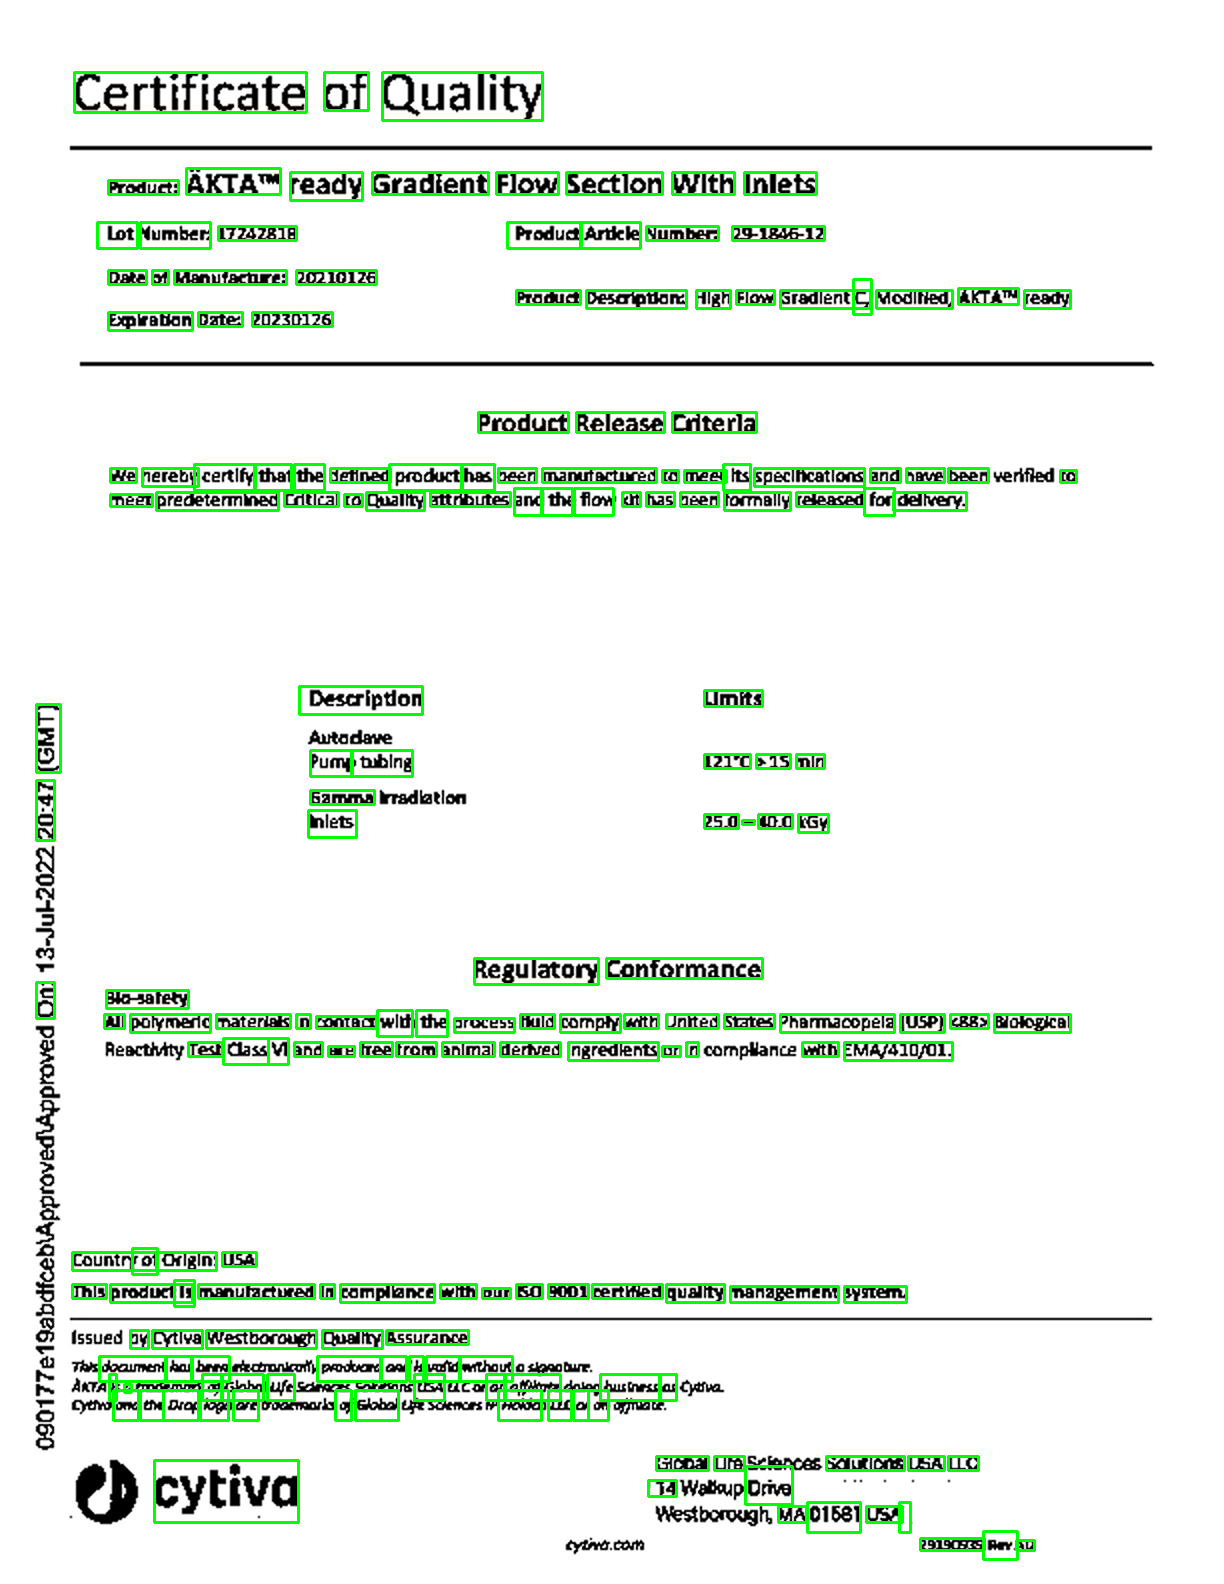

In [4]:
!apt install -y tesseract-ocr  # Install Tesseract OCR
!pip install pymupdf pytesseract opencv-python pillow numpy  # Install required Python libraries
import cv2
import pytesseract
import fitz  # PyMuPDF
import numpy as np
from PIL import Image
from google.colab import files
import os
# Load the scanned PDF
print("Upload your Pharmaceutical SDF (PDF file):")
uploaded = files.upload()

# Get the uploaded filename
pdf_filename = list(uploaded.keys())[0]
pdf_path = f"/content/{pdf_filename}"
print(f"\nUploaded: {pdf_filename}")
doc = fitz.open(pdf_path)

# Get the first page of our PDF
page = doc[0]

# Try to extract text the normal way
text = page.get_text("text")

print("Attempting direct text extraction (without OCR):")
print("-" * 50)
if text.strip():
    print(text[:500])  # Show first 500 characters
else:
    print("[EMPTY] - No text found! This PDF is a scanned image.")
    print("This is why we need OCR - to 'read' the picture of text!")

# Convert the page to pixels (an image)
pix = page.get_pixmap()

# Convert to a format we can work with
img = np.array(Image.frombytes("RGB", [pix.width, pix.height], pix.samples))

# Display the original image
print("Here's your pharmaceutical document as an image:")
display(Image.fromarray(img))

# Convert the image to grayscale
img = np.array(img)  # Convert PIL image to NumPy array
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
# Apply adaptive thresholding to enhance contrast
gray = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
# Apply Bilateral Filtering for noise reduction
gray = cv2.bilateralFilter(gray, 9, 75, 75)
# Resize image for better OCR accuracy
scale_percent = 200  # Increase image size by 200%
width = int(gray.shape[1] * scale_percent / 100)
height = int(gray.shape[0] * scale_percent / 100)
gray = cv2.resize(gray, (width, height), interpolation=cv2.INTER_CUBIC)
# TIP: If OCR is still missing small text, try scale_percent = 300!

# Configure Tesseract for best results
# --oem 3: Use the neural network engine (most accurate)
# -l eng: Language is English
custom_config = r'--oem 3 -l eng'

# Run OCR!
ocr_text = pytesseract.image_to_string(gray, config=custom_config)

print("=" * 50)
print("OCR EXTRACTED TEXT")
print("=" * 50)
print(ocr_text)

import re

# Step 11.1: Remove extra spaces and line breaks
ocr_text_clean = " ".join(ocr_text.split())

# Step 11.2: Fix common OCR errors in pharmaceutical documents
# These are words where OCR often mistakes numbers for letters
ocr_text_clean = re.sub(r'\bL0T\b', 'LOT', ocr_text_clean, flags=re.IGNORECASE)
ocr_text_clean = re.sub(r'\bC0A\b', 'COA', ocr_text_clean, flags=re.IGNORECASE)
ocr_text_clean = re.sub(r'\bCERT1FICATE\b', 'CERTIFICATE', ocr_text_clean, flags=re.IGNORECASE)
ocr_text_clean = re.sub(r'\bEXP1RATION\b', 'EXPIRATION', ocr_text_clean, flags=re.IGNORECASE)
ocr_text_clean = re.sub(r'\bPR0CESSING\b', 'PROCESSING', ocr_text_clean, flags=re.IGNORECASE)
ocr_text_clean = re.sub(r'\bMANUFACTUR1NG\b', 'MANUFACTURING', ocr_text_clean, flags=re.IGNORECASE)

# Step 11.3: Remove any weird symbols that aren't useful
ocr_text_clean = re.sub(r'[^a-zA-Z0-9\s,.%-/:]', '', ocr_text_clean)

print("=" * 50)
print("CLEANED OCR TEXT")
print("=" * 50)
print(ocr_text_clean)



# Get detailed OCR data including positions
ocr_data = pytesseract.image_to_data(gray, output_type=pytesseract.Output.DICT)

# Show the first 10 detected words and their locations
print("Sample of detected words with bounding boxes:")
print("-" * 60)
count = 0
for i in range(len(ocr_data["text"])):
    word = ocr_data["text"][i].strip()
    if word:  # Only show non-empty words
        x = ocr_data["left"][i]
        y = ocr_data["top"][i]
        w = ocr_data["width"][i]
        h = ocr_data["height"][i]
        conf = ocr_data["conf"][i]
        print(f"Word: '{word}'  Position: ({x}, {y})  Size: {w}x{h}  Confidence: {conf}%")
        count += 1
        if count >= 10:
            break

print(f"\n...and {len([t for t in ocr_data['text'] if t.strip()])} total words detected!")

# TIP: The confidence score (0-100) tells you how sure Tesseract is.
# Make a copy of the grayscale image and Convert to color so we can draw colored boxes
img_with_boxes = cv2.cvtColor(gray.copy(), cv2.COLOR_GRAY2BGR)

# Set minimum confidence threshold (Scores below 40 are often mistakes)
confidence_threshold = 40

# Loop through all detected words
for i in range(len(ocr_data["text"])):
    word = ocr_data["text"][i].strip()
    conf = int(ocr_data["conf"][i])

    # Skip empty words or low-confidence detections
    if not word or conf < confidence_threshold:
        continue

    # Get bounding box coordinates
    x = ocr_data["left"][i]
    y = ocr_data["top"][i]
    w = ocr_data["width"][i]
    h = ocr_data["height"][i]

    # Draw a green rectangle
    cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

print("All detected words with bounding boxes (green):")
# Convert BGR to RGB for display
display(Image.fromarray(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)))

# TIP: If you see boxes around noise/artifacts, increase confidence_threshold!


In [5]:
# Install PaddleOCR and a compatible version of PaddlePaddle
# We pin specific versions to avoid compatibility issues
#PaddleOCR needs several tools to work:
# - PaddlePaddle: The engine that powers PaddleOCR (like a car engine)
# - pdf2image + poppler: Convert PDF pages into images
# - langchain: Required by PaddleOCR's internal components
!pip install paddleocr==2.9.1 paddlepaddle==2.6.2

# Install PDF conversion tools and langchain (needed by PaddleOCR internals)
!pip install pdf2image langchain langchain-text-splitters

# Install poppler (system tool that helps convert PDFs to images)
!apt-get update
!apt-get install poppler-utils -y

print("\n" + "=" * 50)
print("All dependencies installed!")
print("=" * 50)
print("\n⚠️  NOW: Go to Runtime → Restart session")
print("Then SKIP this cell and run the next one.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tifffile to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.7/544.7 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.9/161.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.2 MB/s 

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,332 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,308 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [

Compatibility fix applied successfully!
All libraries imported successfully!
Upload your Pharmaceutical SDF (PDF file):


Saving pharmaceutical-sdf-page3-certificate-quality (1).pdf to pharmaceutical-sdf-page3-certificate-quality (1) (1).pdf

Uploaded: pharmaceutical-sdf-page3-certificate-quality (1) (1).pdf

Converting PDF to image...
Converted 1 page(s)


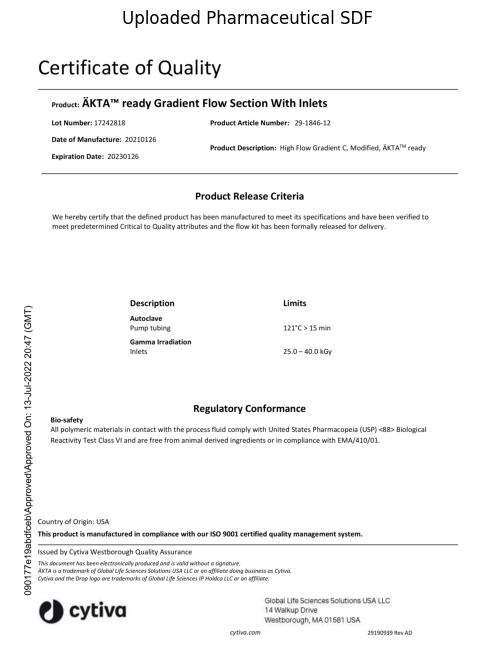

Initializing PaddleOCR (this may download model files)...
download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 3910/3910 [00:20<00:00, 193.06it/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10000/10000 [00:02<00:00, 4354.27it/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2138/2138 [00:17<00:00, 119.05it/s]

[2026/07/04 19:44:05] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_length=25, rec_c


PaddleOCR initialized and ready!
Running PaddleOCR on your pharmaceutical document...
(This may take a moment)
[2026/07/04 19:44:07] ppocr DEBUG: dt_boxes num : 36, elapsed : 0.4955275058746338
[2026/07/04 19:44:07] ppocr DEBUG: cls num  : 36, elapsed : 0.11879324913024902
[2026/07/04 19:44:30] ppocr DEBUG: rec_res num  : 36, elapsed : 22.359487056732178

OCR complete!
Detected 36 text regions
Sample of PaddleOCR Results:
 1. [99.94%] Certificate of Quality
 2. [96.58%] Product: AKTArM ready Gradient Flow Section With Inlets
 3. [99.11%] Lot Number: 17242818
 4. [99.02%] Product Article Number: 29-1846-12
 5. [99.81%] Date of Manufacture: 20210126
 6. [99.70%] Product Description: High Flow Gradient C, Modified, AKTATM ready
 7. [98.90%] Expiration Date: 20230126
 8. [97.57%] Product Release Criteria.
 9. [98.20%] We hereby certify that the defined product has been manufactured to meet its specifications and have been verified to
10. [98.49%] meet predetermined Critical to Quality att

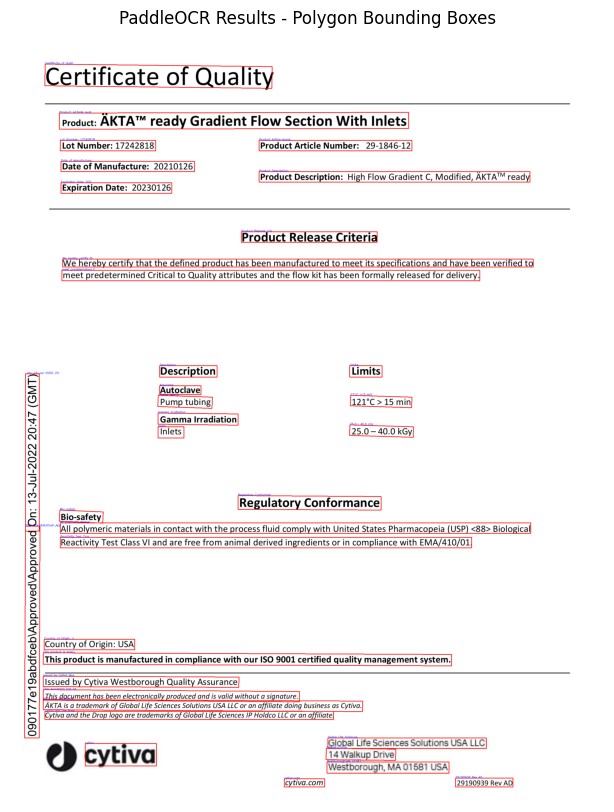

In [1]:
import sys
import types

# Create compatibility bridges for old import paths
# Bridge 1: langchain.docstore.document → langchain_core.documents
m1 = types.ModuleType("langchain.docstore.document")
from langchain_core.documents import Document
m1.Document = Document
sys.modules["langchain.docstore.document"] = m1

# Bridge 2: langchain.text_splitter → langchain_text_splitters
m2 = types.ModuleType("langchain.text_splitter")
from langchain_text_splitters import RecursiveCharacterTextSplitter
m2.RecursiveCharacterTextSplitter = RecursiveCharacterTextSplitter
sys.modules["langchain.text_splitter"] = m2

print("Compatibility fix applied successfully!")

# PaddleOCR tries to import from an older version of langchain,
# but Colab has a newer version installed. This fix bridges that gap.
# Without it, you'd get an error when trying to import PaddleOCR.
# importing libraries
from paddleocr import PaddleOCR
from pdf2image import convert_from_path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import cv2
import numpy as np
from google.colab import files
import os

print("All libraries imported successfully!")
print("Upload your Pharmaceutical SDF (PDF file):")
uploaded = files.upload()

# Get the uploaded filename
pdf_filename = list(uploaded.keys())[0]
pdf_path = f"/content/{pdf_filename}"
print(f"\nUploaded: {pdf_filename}")

# Convert PDF to images (high quality)
print("\nConverting PDF to image...")
images = convert_from_path(pdf_path, dpi=300)
print(f"Converted {len(images)} page(s)")

# Save the first page as an image
image = images[0]
image_path = '/content/pharmaceutical_sdf.png'
image.save(image_path, 'PNG')

# Display the image
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.title('Uploaded Pharmaceutical SDF')
plt.axis('off')
plt.show()

print("Initializing PaddleOCR (this may download model files)...")

# Initialize PaddleOCR
ocr = PaddleOCR(
    use_angle_cls=True,  # Enable text angle detection
    lang='en'            # English language
)

print("\nPaddleOCR initialized and ready!")

print("Running PaddleOCR on your pharmaceutical document...")
print("(This may take a moment)")

# Run OCR
result = ocr.ocr(image_path)

print("\nOCR complete!")
print(f"Detected {len(result[0]) if result[0] else 0} text regions")

#showing what PaddleOCR found
print("Sample of PaddleOCR Results:")
print("=" * 60)

# Show first 15 results
for i, line in enumerate(result[0][:15]):
    box = line[0]  # Polygon coordinates
    text = line[1][0]  # Detected text
    confidence = line[1][1]  # Confidence score

    print(f"{i+1:2d}. [{confidence:.2%}] {text}")

if len(result[0]) > 15:
    print(f"\n... and {len(result[0]) - 15} more text regions!")

# TIP: Confidence scores above 90% are usually very reliable.

# Load the original image with OpenCV
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for display

# Draw polygons for each detected text region
for line in result[0]:
    box = line[0]  # Get the polygon coordinates
    text = line[1][0]  # Get the text
    score = line[1][1]  # Get confidence

    # Only draw for high-confidence detections
    if score > 0.5:
        # Convert box coordinates to integers
        box = [(int(x), int(y)) for x, y in box]

        # Draw the polygon (4-sided shape) in red
        cv2.polylines(img, [np.array(box)], isClosed=True,
                      color=(255, 0, 0), thickness=2)

        # Add the text label near the first corner in blue
        cv2.putText(img, text[:20], box[0],
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

# Display the result
plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.title('PaddleOCR Results - Polygon Bounding Boxes')
plt.axis('off')
plt.show()

# Notice how polygons can capture tilted text better than rectangles!

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 21.8 MB/s eta 0:00:00

EasyOCR installed and imported!
Upload your Pharmaceutical SDF (PDF file):


Saving pharmaceutical-sdf-page3-certificate-quality (1).pdf to pharmaceutical-sdf-page3-certificate-quality (1) (2).pdf


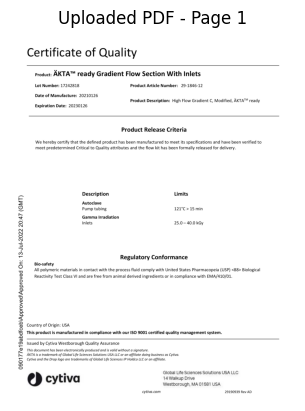

Initializing EasyOCR reader...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR reader ready!
Running EasyOCR on your pharmaceutical document...

EasyOCR found 47 text regions!
Sample of EasyOCR Results:
 1. [96.69%] Certificate of Quality
 2. [99.99%] Product:
 3. [81.38%] AKTATm
 4. [87.09%] ready Gradient Flow Section With Inlets
 5. [67.32%] Lot Number: 17242818
 6. [83.82%] Product Article Number:
 7. [98.10%] 29-1846-12
 8. [95.51%] Date of Manufacture: 20210126
 9. [83.95%] Product Description: High Flow Gradient C, Modified, AKTATM ready
10. [96.32%] Expiration Date: 20230126
11. [77.22%] Product Release Criteria
12. [81.51%] We hereby certify that the defined product has been manufactured to meet its specifications and have been verified to
13. [100.00%] meet
14. [72.91%] predetermined Critical to Quality attributes and the flow kit has been formally released for delivery:
15. [100.00%] Description

... and 32 more text regions!


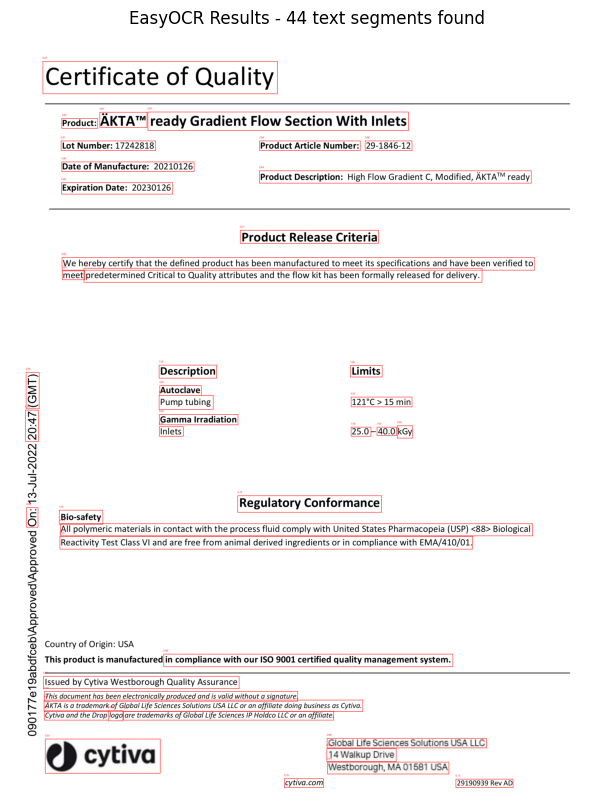

In [2]:
!pip install easyocr

import easyocr

print("\nEasyOCR installed and imported!")

from google.colab import files
from pdf2image import convert_from_path
from PIL import Image
import matplotlib.pyplot as plt
print("Upload your Pharmaceutical SDF (PDF file):")
# Upload your file
uploaded = files.upload()
pdf_path = f"/content/{list(uploaded.keys())[0]}"

# Convert first page to image
images = convert_from_path(pdf_path, dpi=300)
image = images[0]
image_path = '/content/page.png'
image.save(image_path)

# Show preview
plt.imshow(image)
plt.axis('off')
plt.title("Uploaded PDF - Page 1")
plt.show()

print("Initializing EasyOCR reader...")
# Create a reader for English
reader = easyocr.Reader(['en'])

print("EasyOCR reader ready!")

# TIP: You can add more languages like ['en', 'fr'] for multilingual documents.
print("Running EasyOCR on your pharmaceutical document...")

# Run OCR
easy_result = reader.readtext(image_path)

print(f"\nEasyOCR found {len(easy_result)} text regions!")
#showing what EasyOCR found
print("Sample of EasyOCR Results:")
print("=" * 60)

# Show first 15 results
for i, (bbox, text, confidence) in enumerate(easy_result[:15]):
    print(f"{i+1:2d}. [{confidence:.2%}] {text}")

if len(easy_result) > 15:
    print(f"\n... and {len(easy_result) - 15} more text regions!")
# Load a fresh copy of the image
img_easy = image.copy()
draw = ImageDraw.Draw(img_easy)

# Collect high-confidence text
extracted_text = []

for (bbox, text, confidence) in easy_result:
    if confidence > 0.5:  # Only show high-confidence results
        # Get bounding box corners
        top_left = tuple(map(int, bbox[0]))
        bottom_right = tuple(map(int, bbox[2]))

        # Draw rectangle
        draw.rectangle([top_left, bottom_right], outline='red', width=2)

        # Add confidence score
        draw.text((top_left[0], top_left[1] - 20), f"{confidence:.2f}", fill='red')

        extracted_text.append(text)

# Display
plt.figure(figsize=(15, 10))
plt.imshow(img_easy)
plt.title(f'EasyOCR Results - {len(extracted_text)} text segments found')
plt.axis('off')
plt.show()

In [5]:
#Compare OCR Engine Statistics
# Calculate statistics for TesseractOCR
# Filter out empty strings and convert confidence to float (0-1 range)
tesseract_filtered_data = [(text, float(conf)/100) for text, conf in zip(ocr_data['text'], ocr_data['conf']) if text.strip() != '']
tesseract_count = len(tesseract_filtered_data)
tesseract_confidences = [conf for text, conf in tesseract_filtered_data]
tesseract_avg_conf = sum(tesseract_confidences) / tesseract_count if tesseract_count > 0 else 0

# Calculate statistics for PaddleOCR
paddle_count = len(result[0]) if result[0] else 0
paddle_confidences = [line[1][1] for line in result[0]] if result[0] else []
paddle_avg_conf = sum(paddle_confidences) / len(paddle_confidences) if paddle_confidences else 0

# Calculate statistics for EasyOCR
easy_count = len(easy_result)
easy_confidences = [conf for (_, _, conf) in easy_result]
easy_avg_conf = sum(easy_confidences) / len(easy_confidences) if easy_confidences else 0

# Print comparison
print("OCR Engine Comparison")
print("=" * 70)
print(f"{'Metric':<25} {'PaddleOCR':<15} {'EasyOCR':<15} {'TesseractOCR':<15}")
print("-" * 70)
print(f"{'Text regions detected:':<25} {paddle_count:<15} {easy_count:<15} {tesseract_count:<15}")
print(f"{'Average confidence:':<25} {f'{paddle_avg_conf:.2%}':<15} {f'{easy_avg_conf:.2%}':<15} {f'{tesseract_avg_conf:.2%}':<15}")
print(f"{'High conf (>90%):':<25} {sum(1 for c in paddle_confidences if c > 0.9):<15} {sum(1 for c in easy_confidences if c > 0.9):<15} {sum(1 for c in tesseract_confidences if c > 0.9):<15}")
print(f"{'Low conf (<50%):':<25} {sum(1 for c in paddle_confidences if c < 0.5):<15} {sum(1 for c in easy_confidences if c < 0.5):<15} {sum(1 for c in tesseract_confidences if c < 0.5):<15}")

# TIP: More detections isn't always better - accuracy matters too!


OCR Engine Comparison
Metric                    PaddleOCR       EasyOCR         TesseractOCR   
----------------------------------------------------------------------
Text regions detected:    36              47              219            
Average confidence:       98.41%          79.12%          74.68%         
High conf (>90%):         36              17              101            
Low conf (<50%):          0               3               43             
